# Projeto IIA

Grupo AQ

- Juniper Wilson 61795
- Jaime Sousa 58171
- Miguel Zhang 61829

Contribuições do grupo:

- Juniper 33%
- Jaime 33%
- Miguel 33%

## Estrategia

Reparem no seguinte acerca dos problemas:

Um de classificação: 
O1

Outros dois de regressão:
O2 e O3

O objetivo O4 é resolvido no notebook da TP08: Feature selection

O nosso metodo de trabalho deve passar por:

1) Induzir os dados ausentes (Data Imputing)
2) Reduzir as features triviais usando Spearman (Feature Selection)
3) Construir classificadores/regressores demonstrados nas tps
4) Pontuar e escolher os classificadores
5) Otimizando os seus hyperparametros

In [1]:

import sys
from pathlib import Path

# Make project root importable regardless of notebook working directory
cwd = Path.cwd()
project_root = cwd if (cwd / "src").exists() else cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from sklearn.feature_selection import SequentialFeatureSelector 
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler

# Scikit-learn: models
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import LinearSVC
from sklearn.svm import LinearSVR
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

# Scikit-learn: model selection
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split

# Scikit-learn: metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import mean_squared_error
from sklearn.metrics import precision_score
from sklearn.metrics import r2_score
from sklearn.metrics import recall_score
from sklearn.metrics import root_mean_squared_error

# Our methods
from src.load import load_spaceship_data


## Preprocessing
For preprocessing on the classification problem O1, we only did imputation of the missing values, since scaling is not strictly necessary for our implementation using Decision Trees

For preprocessing on the regression problems O2 and 03, we started by standardizing the numeric columns, and then imputing missing values with KNNImputer for the numeric columns and SimpleImputer with the most frequent value as the strategy. The boxplots generated when running the regression preprocessing cell shows that the bulk of the values of each features are concentrated between about -1 and 10, ideal for the regression models we used.
### Scaling 
I (Juniper) decided to use standardization to scale the data rather than the other techniques because I created box plots of the data and noticed that the data was not evenly distributed in it's range and had lots of outliers. When I first attempted to use normalization as a scaling method, the outliers compressed the bulk of the data into just a tiny sliver of the range, which might result in lost precision due to floating point errors. Therefore I decided on standardization. 
### Imputing
As far as imputing the missing values, two different methods had to be used because some of the columns are numerical and others are categorical. I decided on KNN imputation because it is multivariate. I thought this data set would benefit from a multivariate technique, because all the features must be taken into account to determine the transported passengers, and a univariate method might miss out on some of the hidden complexities. For the categorical columns I used the simpler SimpleImputer because it's "most_frequent" strategy works well for categorical data.

In [ ]:
import load as load_module

#path
data_path = "../data/spaceship_data.csv"

raw_df = load_module.load_spaceship_data_as_df(data_path)

# I split the data frame into numerical and categorical columns, so that each can be scaled and imputted appropriately.
numerical_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
categorical_cols = ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name', 'Transported']

In [ ]:
# Preprocessing for classification problem
import preprocessing as preprocessing_module

numerical_df = raw_df.loc[:, numerical_cols]
categorical_df = raw_df.loc[:, categorical_cols]

df_classification = preprocessing_module.impute(numerical_cols, categorical_cols, numerical_df, categorical_df)

<Axes: >

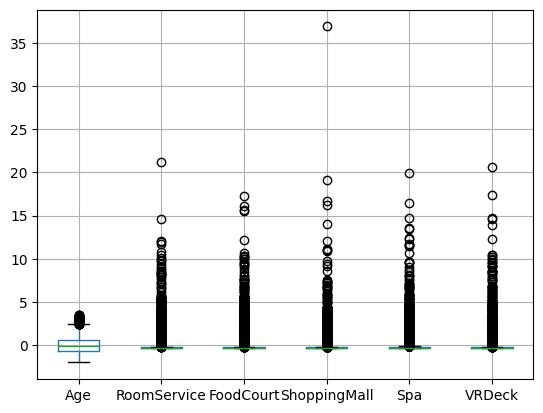

In [9]:
# Preprocessing for regression problems
numerical_df = raw_df.loc[:, numerical_cols]
categorical_df = raw_df.loc[:, categorical_cols]

standardized_df = preprocessing_module.standardize(numerical_cols, categorical_cols, numerical_df, categorical_df)

numerical_df = standardized_df.loc[:, numerical_cols]
categorical_df = standardized_df.loc[:, categorical_cols]

df_regression = preprocessing_module.impute(numerical_cols, categorical_cols, numerical_df, categorical_df)

df_regression.boxplot()

## Feature Selection (O4)

Decidimos utilizar seleção de variaveis para acelerar o treino das nossas maquinas de aprendizagem. Tomamos essa decisão por acreditar que certas variaveis como, por exemplo, o ID não estivessem relacionadas com as targets. 

Usaremos a correlação Spearman para confirmar as nossas suspeitas e descobrir que variaveis são mais importantes para os problemas.

Acreditamos também que nesta consideração conseguimos responder à questão O4:  Quais  são  os  atributos  mais  importantes  nos  modelos O1, O2, O3?

In [7]:
# O4.1: Spearman correlation for O1, O2 and O3 using load.py
import importlib
from spearman import spearman_with_target

# O1: classification target
spearman_o1 = spearman_with_target(data_path, "Transported")
print("O1: Spearman Correlation with Target Transported:")
print(spearman_o1)
print("\n")

# O2: regression target
spearman_o2 = spearman_with_target(data_path, "FoodCourt")
print("O2: Spearman Correlation with Target FoodCourt:")
print(spearman_o2)
print("\n")

# O3: regression target, filtered to passengers that were transported
spearman_o3 = spearman_with_target(data_path, "Age", filter_col="Transported", filter_value=True)
print("O3: Spearman Correlation with Target Age (Transported=True only):")
print(spearman_o3)
print("\n")

print("Low correlation means the feature is not strongly related to the target. Consider dropping it.")

O1: Spearman Correlation with Target Transported:
              correlation        p_value
CryoSleep        0.458955   0.000000e+00
RoomService     -0.367189  6.087397e-221
Spa             -0.363072  1.060938e-215
VRDeck          -0.344708  3.033668e-193
ShoppingMall    -0.222237   1.480313e-78
FoodCourt       -0.176329   1.124358e-49
HomePlanet       0.138180   5.426828e-31
Destination     -0.101958   1.554600e-17
Age             -0.060485   4.473372e-07
Cabin           -0.056653   2.275076e-06
VIP             -0.033039   5.862320e-03
Name            -0.016093   1.796545e-01
PassengerId      0.013858   2.479049e-01


O2: Spearman Correlation with Target FoodCourt:
              correlation        p_value
CryoSleep       -0.524488   0.000000e+00
VRDeck           0.495686   0.000000e+00
Spa              0.465011   0.000000e+00
Cabin           -0.272895  5.183831e-119
Age              0.201339   1.602951e-64
ShoppingMall     0.181943   7.950937e-53
Transported     -0.176329   1.124358e-4

/home/juniper/Documents/Schoo/IIA/thirdyear/aai/src/spearman.py:63: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = stats.spearmanr(series, y_s)


### Conclusão

Dadas as baixas correlações, decidimos dropar as colunas:

O1: PassengerId, Name

O2: PassengerId, Destination, HomePlanet, Name

O3: CryoSleep, PassengerId, Name, Destination

Obs: Dropa-se também Transported em O3 dada a natureza do problema


In [8]:
import pandas as pd

# O1: Drop PassengerId and Name
df_o1 = df_classification.drop(columns=["PassengerId", "Name"])

# O2: Drop PassengerId, Name, Destination, HomePlanet
df_o2 = df_regression.drop(columns=["PassengerId", "Name", "Destination", "HomePlanet"])

# O3: Filter to Transported=True, then drop PassengerId, Name, Destination, CryoSleep, Transported
df_o3 = df_regression[df_regression["Transported"] == True].drop(columns=["PassengerId", "Name", "Destination", "CryoSleep", "Transported"])

# Debugging: print shapes of the resulting dataframes
print(f"O1 shape: {df_o1.shape}")
print(f"O2 shape: {df_o2.shape}")
print(f"O3 shape: {df_o3.shape}")

O1 shape: (6954, 12)
O2 shape: (6954, 10)
O3 shape: (3502, 9)


#### Resposta à Questão O4

Concluimos também que as variaveis mais importantes as com uma correlação maior com a target são as seguintes, por ordem decrescente de importância:

O1: CryoSleep, RoomService, Spa, VRDeck

O2: CryoSleep, VRDeck, Spa, Cabin, Age

O3: Cabin, HomePlanet, FoodCourt, Spa, VRDeck

#### Observação adicional O3

As correlações mais baixas em O3 sugerem que não é possivel prever com tanta previsibilidade a target Age como nos outros problemas 

# Exemplo de um classificador

In [6]:
# Load the raw data
import importlib
import sys
from pathlib import Path

import pandas as pd

# Make project root importable regardless of notebook working directory
cwd = Path.cwd()
project_root = cwd if (cwd / "src").exists() else cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.statistics import present_classification_statistics
import src.load as load_module
importlib.reload(load_module)

raw_df = load_module.load_spaceship_data_as_df(str(project_root / "data" / "spaceship_data.csv"))
y = raw_df["Transported"].astype(int)
X = raw_df.drop(columns=["Transported", "PassengerId", "Name"], errors='ignore')

# Basic preprocessing so the tree can train on numeric data
for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col] = X[col].fillna(X[col].median())
    else:
        X[col] = X[col].fillna(X[col].mode().iloc[0])

X = pd.get_dummies(X, drop_first=True)

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Train DecisionTreeClassifier
clf = DecisionTreeClassifier(max_depth=10, min_samples_split=5, random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Print metrics
present_classification_statistics(y_test, y_pred)

=== DECISION TREE CLASSIFIER METRICS ===

Confusion Matrix:
[[486 230]
 [113 562]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.68      0.74       716
           1       0.71      0.83      0.77       675

    accuracy                           0.75      1391
   macro avg       0.76      0.76      0.75      1391
weighted avg       0.76      0.75      0.75      1391

Precision: 0.7619737501198814
Recall: 0.7534148094895758
F1-Score: 0.7522782018326476
Matthews Correlation Coefficient: 0.5161336297331891


# Problema de Classificação:

## O1:  Prever  a  variável  Transported  dados  os  atributos  do  dataset fornecido


### Solution

In [28]:
import importlib
import sys
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from src.statistics import best_model_simple

df_o1 = df_o1.sample(n=min(100, len(df_o1)), random_state=42).reset_index(drop=True)

y = df_o1["Transported"].astype(int)
X = df_o1.drop(columns=["Transported", "PassengerId", "Name"], errors="ignore")

# Convert string categories like Earth, Mars and Europa into numeric features
X = pd.get_dummies(X, drop_first=True)

#splits the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Instantiate classifiers
knn_clf = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
linear_svc = LinearSVC(max_iter=10000, random_state=42).fit(X_train, y_train)
svc_clf = SVC(probability=True, random_state=42).fit(X_train, y_train)
dt_clf = DecisionTreeClassifier(max_depth=10, random_state=42).fit(X_train, y_train)

#chat dont erase these lines, they are needed for the next step

models = [knn_clf, linear_svc, svc_clf, dt_clf]

# Não usar r2_score para classificação, usar f1_score ou accuracy_score
best_model_name, best_model_score = best_model_simple(models, X_test, y_test)
print("Best model (simple):", best_model_name, best_model_score)

# quick check
print('Created classifiers:', knn_clf, linear_svc, svc_clf, dt_clf)

Best model (simple): SVC 0.12087912087912067
Created classifiers: KNeighborsClassifier() LinearSVC(max_iter=10000, random_state=42) SVC(probability=True, random_state=42) DecisionTreeClassifier(max_depth=10, random_state=42)


/home/juniper/Documents/Schoo/IIA/thirdyear/aai/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


## O2: Prever  o  valor  dispendido  pelos  passageiros  em  restaurantes (variável FoodCourt) 
### Solution

        Age  RoomService  ShoppingMall       Spa    VRDeck  CryoSleep_False  \
0 -1.237210    -0.337349     -0.281113 -0.276385 -0.265843            False   
1  0.073323    -0.337349     -0.281113 -0.276385 -0.265843            False   
2  0.556151    -0.337349     -0.281113 -0.276385 -0.265843            False   
3 -0.547456     0.094676     -0.255791 -0.172422 -0.113933             True   
4  0.073323     0.893997     -0.277948  2.395910  1.740239             True   

   CryoSleep_True  Cabin_A/16/S  Cabin_B/118/S  Cabin_B/127/P  ...  \
0            True         False          False          False  ...   
1            True         False          False          False  ...   
2            True         False          False          False  ...   
3           False         False          False          False  ...   
4           False         False          False          False  ...   

   Cabin_G/779/S  Cabin_G/811/S  Cabin_G/839/P  Cabin_G/906/P  Cabin_G/907/P  \
0          False        

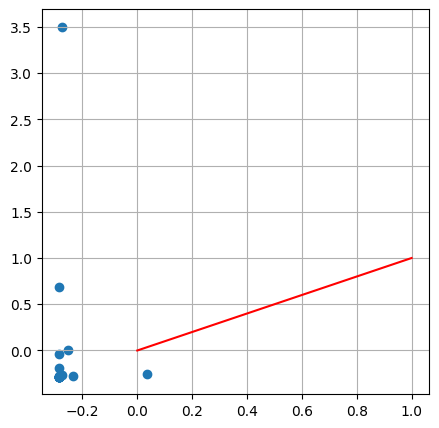

'\nUsa os metodos em statistics.py para escolher o melhor modelo (metodo: best_model_simple e best_model_weighted)\n\nVais curtir bue daquilo :P\n'

In [46]:
# O2 analysis (see O4.1 for Spearman correlations)

#JUNE!!!
import matplotlib.pyplot as plt
from sklearn import tree

df_o2 = df_o2.sample(n=min(100, len(df_o2)), random_state=42).reset_index(drop=True)
# df_o2['Cabin'] = pd.get_dummies(df_o2['Cabin'])
df_o2 = pd.get_dummies(df_o2)

y = df_o2["FoodCourt"]
X = df_o2.drop(columns=["FoodCourt"], errors="ignore")

print(X.head(5))

#splits the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# X = pd.get_dummies(X)

rt = tree.DecisionTreeRegressor()
rt.fit(X_train, y_train)
preds=rt.predict(X_test)

plt.figure(figsize=(5,5))
plt.scatter(preds, y_test)
plt.plot((0, 1), (0,1), c="r")
plt.grid()
plt.show()
"""
Usa os metodos em statistics.py para escolher o melhor modelo (metodo: best_model_simple e best_model_weighted)

Vais curtir bue daquilo :P
"""

## O3:  É  possível  prever  com  confiança  a  idade  dos  passageiros  que foram transportados? 
### Solution

In [ ]:
#O3

# MIGUEL!
"""
Vais basicamente dar o teu melhor para construir uma boa maquina de regressão para prever a idade dos passageiros transportados, 
usando o df_o3 que construi. :P

Vais criar modelos de REGRESSÃO, e não de classificação, porque o target é a idade, que é uma variável contínua.
Já ha uns quantos bons imports na primeira celula do notebook, mas podes usar outros das aulas se achares que te ajudam a construir um modelo melhor.

Depois disso usa os metodos em statistics.py para escolher o melhor modelo (metodo: best_model_simple e best_model_weighted)
"""